In [1]:
# ── Reproducibilidad global ─────────────────────────────────────────
import random, os, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# ── Carga del dataset (compatible con Colab y local) ────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.system("git clone https://github.com/Nicolascresp/Airbnb.git 2>/dev/null || echo 'ya clonado'")
    DATA_PATH     = "Airbnb/listings.csv"
    CALENDAR_PATH = "Airbnb/calendar.csv.gz"
else:
    DATA_PATH     = os.path.join(os.path.dirname(os.path.abspath("__file__")), "listings.csv")
    CALENDAR_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "calendar.csv.gz")

df = pd.read_csv(DATA_PATH)
print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

✅ Dataset cargado: 25,000 filas × 18 columnas


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,NaN,4,33,2018-07-15,0.25,2,198,0,NaN
1,30320,Apartamentos Dana Sol,130907,Danuta Weronika,Centro,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,173,2025-08-27,0.93,17,342,1,NaN
2,30959,Beautiful loft in Madrid Center,132883,Angela,Centro,Embajadores,40.41259,-3.70105,Entire home/apt,NaN,3,8,2017-05-30,0.06,1,0,0,NaN
3,40916,Apartasol Apartamentos Dana,130907,Danuta Weronika,Centro,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,53,2025-09-11,0.29,17,341,4,NaN
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,303845,Arturo,Centro,Justicia,40.41884,-3.69655,Private room,65.0,1,249,2025-09-05,2.78,3,299,41,NaN


In [3]:
df.shape

(25000, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              25000 non-null  int64  
 1   name                            25000 non-null  object 
 2   host_id                         25000 non-null  int64  
 3   host_name                       24903 non-null  object 
 4   neighbourhood_group             25000 non-null  object 
 5   neighbourhood                   25000 non-null  object 
 6   latitude                        25000 non-null  float64
 7   longitude                       25000 non-null  float64
 8   room_type                       25000 non-null  object 
 9   price                           18953 non-null  float64
 10  minimum_nights                  25000 non-null  int64  
 11  number_of_reviews               25000 non-null  int64  
 12  last_review                     

## 1. Descripción inicial del dataset

El dataset utilizado corresponde a publicaciones de Airbnb en Madrid, descargado desde Inside Airbnb. Cada fila representa un alojamiento publicado en la plataforma.

El dataset cuenta con 25.000 observaciones y 18 variables. Incluye información sobre ubicación, tipo de habitación, precio, cantidad de noches mínimas, reviews, disponibilidad anual y cantidad de publicaciones del host.

El problema de Machine Learning elegido será de regresión, con el objetivo de predecir el precio de un alojamiento (`price`) a partir de sus características.

In [5]:
nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje": (df.isnull().sum() / len(df) * 100).round(2)
})

nulos.sort_values("porcentaje", ascending=False)

,nulos,porcentaje
license,15812,63.25
price,6047,24.19
reviews_per_month,5147,20.59
last_review,5147,20.59
host_name,97,0.39
id,0,0.00
name,0,0.00
neighbourhood,0,0.00
neighbourhood_group,0,0.00
host_id,0,0.00


### Análisis de valores faltantes

Se observan valores faltantes principalmente en `license`, `price`, `reviews_per_month` y `last_review`.

La variable `price` tiene 6.047 valores faltantes, lo que representa el 24,19% del dataset. Como `price` será la variable objetivo del modelo, no corresponde imputarla, ya que estaríamos inventando el valor que queremos predecir. Por eso, para el modelado se eliminarán las filas sin precio.

La variable `reviews_per_month` tiene valores faltantes en el 20,59% de los casos. Esto probablemente se deba a alojamientos sin reviews, por lo que puede interpretarse como ausencia de actividad y se podría imputar con 0.

La variable `last_review` también tiene 20,59% de faltantes y está relacionada con la ausencia de reviews. En lugar de usarla directamente, podría transformarse en una variable binaria que indique si el alojamiento tuvo alguna review.

La variable `license` tiene 63,25% de valores faltantes, por lo que inicialmente no parece recomendable usarla como variable predictora principal.

### Clasificación de valores faltantes

Los valores faltantes de `reviews_per_month` y `last_review` parecen ser MNAR, ya que probablemente no faltan al azar sino porque el alojamiento no recibió reviews. Es decir, el faltante tiene significado propio: ausencia de actividad registrada.

Los valores faltantes de `license` también pueden considerarse MNAR, porque la falta de licencia puede estar relacionada con decisiones del anfitrión, regulación o carga incompleta de información.

En el caso de `price`, al ser la variable objetivo, no se imputan los faltantes. Estos registros se eliminan para el modelado, ya que imputar el target implicaría inventar el valor que se busca predecir.

In [6]:
df["price"].describe()

,price
count,18953.000000
mean,156.691447
std,492.255350
min,8.000000
25%,70.000000
50%,110.000000
75%,164.000000
max,25654.000000


In [7]:
df["price"].isnull().sum()

np.int64(6047)

In [8]:
(df["price"] == 0).sum()

np.int64(0)

In [9]:
df_model = df.dropna(subset=["price"]).copy()

df_model.shape

(18953, 18)

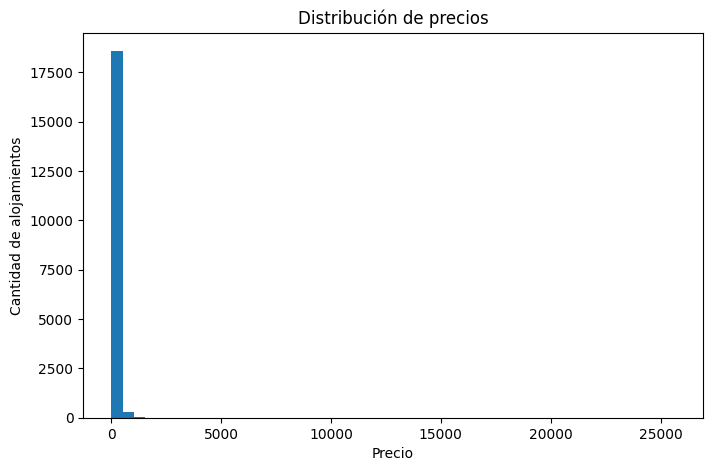

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df_model["price"], bins=50)
plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Cantidad de alojamientos")
plt.show()

In [11]:
df_model["price"].quantile([0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1])

,price
0.00,8.00
0.25,70.00
0.50,110.00
0.75,164.00
0.90,249.00
0.95,343.00
0.99,793.36
1.00,25654.00


### Análisis inicial de la variable objetivo: `price`

La variable `price` será utilizada como target del modelo de regresión. Luego de eliminar los registros sin precio, quedan 18.953 observaciones disponibles para el análisis.

La distribución de precios muestra una fuerte asimetría hacia la derecha. La mediana es 110, mientras que la media es 156,69, lo que indica que algunos valores extremos elevan el promedio. Además, el percentil 99 es 793,36, pero el valor máximo llega a 25.654. Esto sugiere la presencia de outliers muy altos.

Por este motivo, no conviene analizar el precio solo con la media. Será necesario tratar los valores extremos o aplicar una transformación logarítmica para reducir el efecto de los outliers.

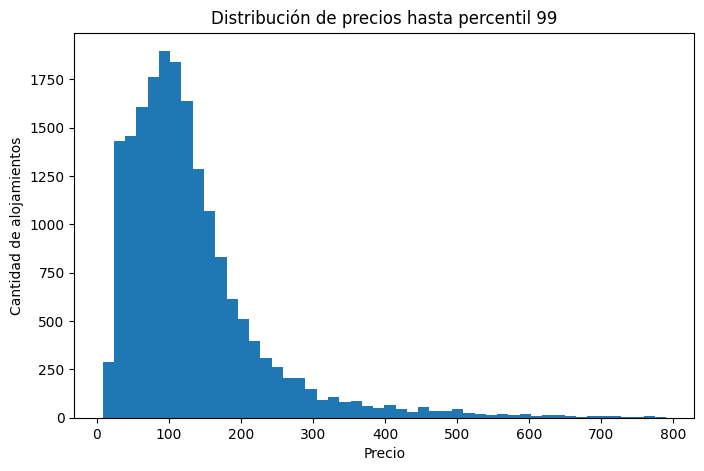

In [12]:
df_model_filtrado = df_model[df_model["price"] <= df_model["price"].quantile(0.99)].copy()

plt.figure(figsize=(8,5))
plt.hist(df_model_filtrado["price"], bins=50)
plt.title("Distribución de precios hasta percentil 99")
plt.xlabel("Precio")
plt.ylabel("Cantidad de alojamientos")
plt.show()

### Distribución de precios sin valores extremos

Para visualizar mejor la distribución de precios, se generó un histograma excluyendo los valores por encima del percentil 99. Esta decisión permite observar el comportamiento de la mayoría de los alojamientos sin que los valores extremos distorsionen el gráfico.

La distribución sigue mostrando asimetría hacia la derecha: la mayoría de los alojamientos se concentra en precios bajos y medios, mientras que hay menos casos con precios altos.

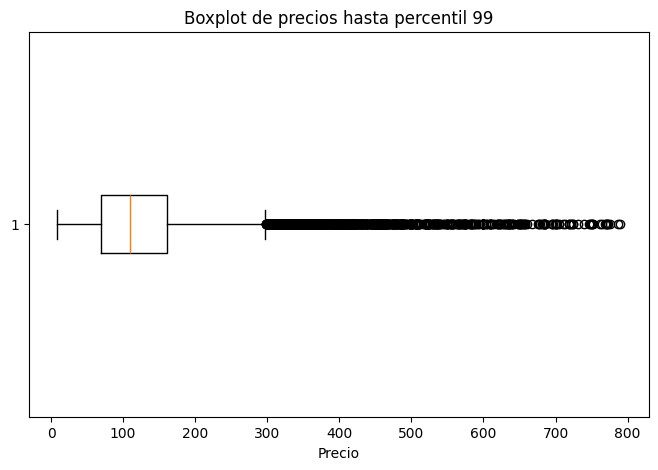

In [13]:
plt.figure(figsize=(8,5))
plt.boxplot(df_model_filtrado["price"], vert=False)
plt.title("Boxplot de precios hasta percentil 99")
plt.xlabel("Precio")
plt.show()

### Outliers en precio

El boxplot permite identificar valores atípicos en la variable `price`. Incluso luego de excluir los valores más extremos, se observan alojamientos con precios superiores al comportamiento típico.

Esto confirma que `price` presenta una distribución sesgada y que será necesario considerar el tratamiento de outliers o una transformación logarítmica antes de entrenar modelos predictivos.

In [14]:
df_model_filtrado["room_type"].value_counts()

,count
room_type,
Entire home/apt,13500
Private room,5076
Shared room,146
Hotel room,41


### Distribución por tipo de habitación

Se analiza la variable `room_type` para entender qué tipos de alojamientos predominan en el dataset. Esta variable es relevante porque el tipo de alojamiento puede influir directamente en el precio.

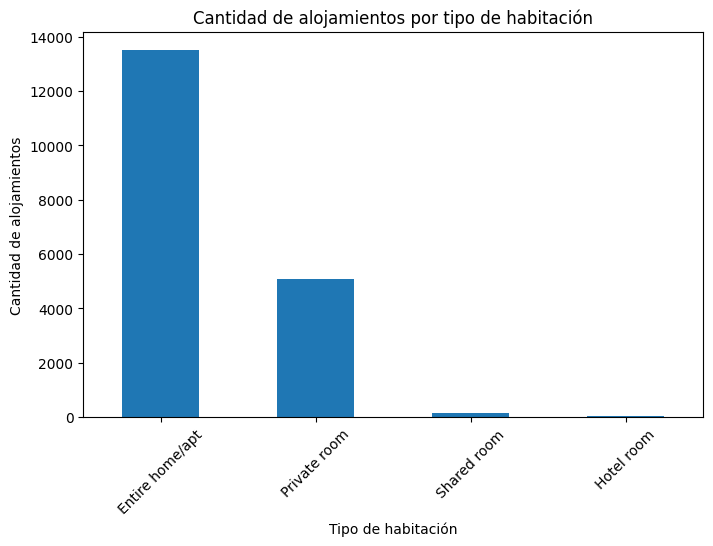

In [15]:
plt.figure(figsize=(8,5))
df_model_filtrado["room_type"].value_counts().plot(kind="bar")
plt.title("Cantidad de alojamientos por tipo de habitación")
plt.xlabel("Tipo de habitación")
plt.ylabel("Cantidad de alojamientos")
plt.xticks(rotation=45)
plt.show()

El gráfico muestra la cantidad de alojamientos según el tipo de habitación. Esta visualización permite identificar qué categorías son más frecuentes dentro del dataset y ayuda a interpretar luego las diferencias de precio entre tipos de alojamiento.

<Figure size 800x500 with 0 Axes>

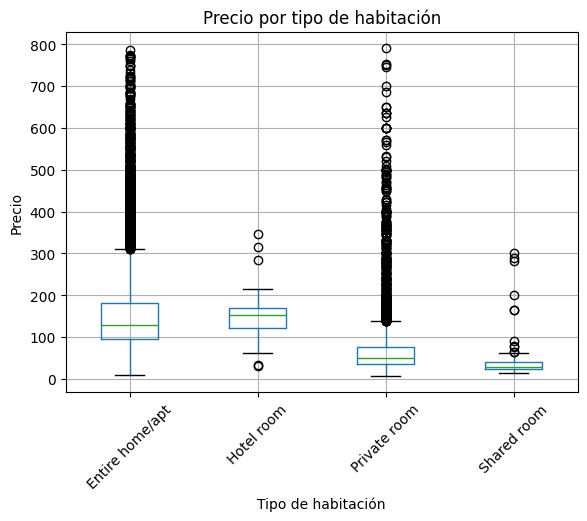

In [16]:
plt.figure(figsize=(8,5))
df_model_filtrado.boxplot(column="price", by="room_type")
plt.title("Precio por tipo de habitación")
plt.suptitle("")
plt.xlabel("Tipo de habitación")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.show()

In [17]:
df_model_filtrado.groupby("room_type")["price"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,13500.0,154.43,94.44,9.0,95.0,128.0,181.0,786.0
Hotel room,41.0,151.10,63.68,31.0,123.0,152.0,170.0,347.0
Private room,5076.0,72.67,75.69,8.0,36.0,50.0,77.0,790.0
Shared room,146.0,40.23,43.80,15.0,25.0,29.5,40.0,300.0


### Precio por tipo de habitación

El tipo de habitación muestra diferencias claras en el precio. Las categorías `Entire home/apt` y `Hotel room` presentan los precios típicos más altos, con medianas de 128 y 152 respectivamente. Sin embargo, la categoría `Hotel room` tiene muy pocas observaciones, por lo que su interpretación debe tomarse con cautela.

Las habitaciones privadas y compartidas presentan precios considerablemente menores, con medianas de 50 y 29,5. Esto tiene sentido desde el negocio, ya que alquilar una propiedad completa o una habitación de hotel suele ofrecer mayor privacidad y valor percibido que una habitación compartida.

Por este motivo, `room_type` será una variable relevante para el modelo predictivo.

In [18]:
df_model_filtrado["neighbourhood"].value_counts().head(15)

,count
neighbourhood,
Embajadores,1970
Universidad,1696
Palacio,1456
Sol,1093
Justicia,935
Cortes,848
Trafalgar,355
Cuatro Caminos,345
Goya,309


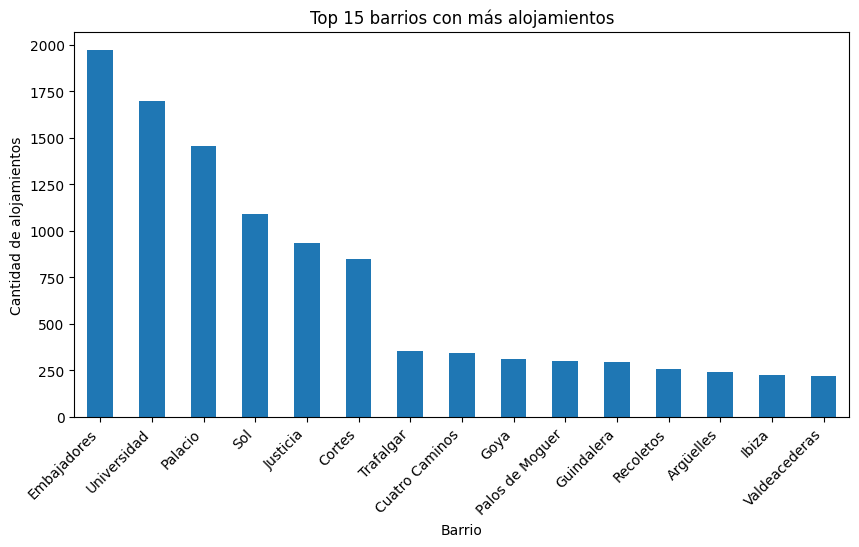

In [19]:
plt.figure(figsize=(10,5))
df_model_filtrado["neighbourhood"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 barrios con más alojamientos")
plt.xlabel("Barrio")
plt.ylabel("Cantidad de alojamientos")
plt.xticks(rotation=45, ha="right")
plt.show()

### Precio Promedio por Barrio (Histograma)

Para visualizar la distribución de precios promedio por barrio, calcularemos el precio promedio para cada barrio y luego mostraremos un histograma de estos promedios. Esto nos ayudará a entender mejor la variabilidad de precios a nivel de barrio y confirmar si `neighbourhood` es una variable útil.

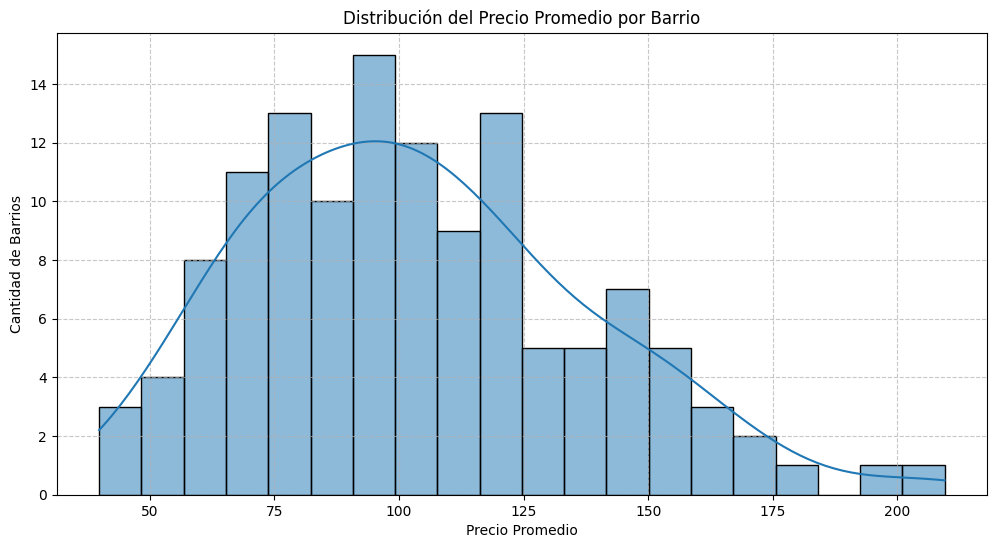

Top 10 barrios con el precio promedio más alto:


,price
neighbourhood,
Recoletos,209.470817
Castellana,200.139241
Goya,178.161812
Sol,173.537969
Cortes,171.528302
Jerónimos,166.435294
Justicia,160.899465
Palacio,159.428571
Rosas,157.964286


In [20]:
import seaborn as sns
# Calcular el precio promedio por barrio
avg_price_per_neighbourhood = df_model_filtrado.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.histplot(avg_price_per_neighbourhood, bins=20, kde=True)
plt.title('Distribución del Precio Promedio por Barrio')
plt.xlabel('Precio Promedio')
plt.ylabel('Cantidad de Barrios')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Top 10 barrios con el precio promedio más alto:")
display(avg_price_per_neighbourhood.head(10))

El gráfico muestra que la oferta de alojamientos no está distribuida de manera uniforme entre los barrios de Madrid. Los barrios con mayor cantidad de publicaciones son `Embajadores`, `Universidad`, `Palacio`, `Sol`, `Justicia` y `Cortes`.

Esto sugiere una concentración importante de alojamientos en zonas céntricas y turísticas. Desde el punto de vista del modelo, `neighbourhood` es conceptualmente una variable muy relevante para explicar diferencias de precio, ya que la ubicación suele influir directamente en el valor de un alojamiento. Sin embargo, otras variables geográficas como la latitud y longitud también capturan esta información de forma granular.

<Figure size 1200x500 with 0 Axes>

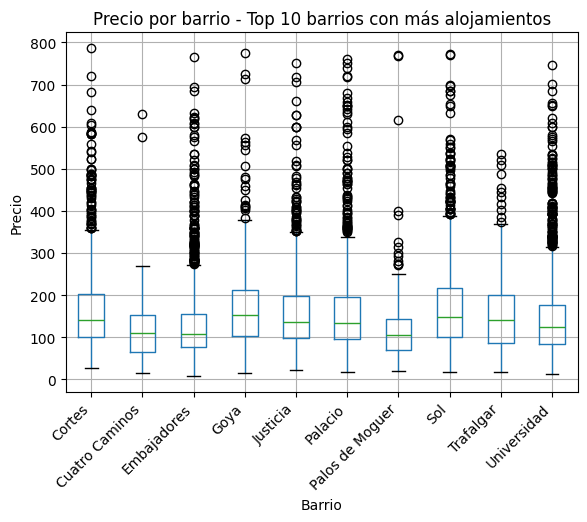

In [21]:
top_barrios = df_model_filtrado["neighbourhood"].value_counts().head(10).index

df_top_barrios = df_model_filtrado[df_model_filtrado["neighbourhood"].isin(top_barrios)]

plt.figure(figsize=(12,5))
df_top_barrios.boxplot(column="price", by="neighbourhood")
plt.title("Precio por barrio - Top 10 barrios con más alojamientos")
plt.suptitle("")
plt.xlabel("Barrio")
plt.ylabel("Precio")
plt.xticks(rotation=45, ha="right")
plt.show()

In [22]:
df_top_barrios.groupby("neighbourhood")["price"].describe().round(2).sort_values("50%", ascending=False)

,count,mean,std,min,25%,50%,75%,max
neighbourhood,,,,,,,,
Goya,309.0,178.16,119.52,15.0,103.00,153.0,213.0,775.0
Sol,1093.0,173.54,110.83,18.0,101.00,148.0,216.0,773.0
Trafalgar,355.0,154.82,93.19,18.0,86.50,142.0,200.0,534.0
Cortes,848.0,171.53,111.99,27.0,100.00,142.0,203.0,786.0
Justicia,935.0,160.90,101.37,22.0,98.00,137.0,199.0,750.0
Palacio,1456.0,159.43,102.19,17.0,95.00,134.0,195.0,761.0
Universidad,1696.0,147.68,101.37,12.0,85.00,125.0,177.0,746.0
Cuatro Caminos,345.0,112.56,68.81,16.0,65.00,110.0,153.0,630.0
Embajadores,1970.0,130.62,88.22,9.0,77.25,108.0,156.0,765.0


El análisis detallado por barrio revela que la ubicación es un factor crítico en la determinación del precio. Hemos observado dos puntos clave:

1.  **Concentración de Oferta:** El gráfico de barras ("Top 15 barrios con más alojamientos") muestra que la oferta de alojamientos no es uniforme. Barrios céntricos y turísticos como `Embajadores`, `Universidad`, `Palacio`, `Sol`, `Justicia` y `Cortes` concentran una gran cantidad de publicaciones. Esto sugiere que estas zonas son altamente demandadas y, por tanto, sus precios pueden comportarse de manera diferente.

2.  **Variabilidad de Precios:** El histograma de "Distribución del Precio Promedio por Barrio" y los boxplots de "Precio por barrio - Top 10 barrios con más alojamientos" confirman que el precio de los alojamientos varía significativamente según el barrio. Por ejemplo, `Goya`, `Sol`, `Trafalgar` y `Cortes` presentan las medianas de precio más altas entre los barrios con más oferta, mientras que `Palos de Moguer` y `Embajadores` muestran precios típicos más bajos. Esta diversidad de precios entre zonas es crucial.

Inicialmente, la inclusión de `neighbourhood` como variable predictora, codificada mediante One-Hot Encoding, parece fundamental para capturar estas diferencias intrínsecas del mercado. Sin embargo, más adelante veremos que, al combinarse con coordenadas geográficas (`latitude`, `longitude`) y la distancia al centro (`dist_centro_km`), la contribución *adicional* de `neighbourhood` en la reducción del error puede volverse marginal. El modelo final buscará un balance entre la información detallada que `neighbourhood` aporta y la redundancia que puede generar junto a otras variables de ubicación.

In [23]:
variables_numericas = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "calculated_host_listings_count",
    "number_of_reviews_ltm"
]

df_model_filtrado[variables_numericas].describe().round(2)

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,calculated_host_listings_count,number_of_reviews_ltm
count,18763.00,18763.00,18763.00,15722.00,18763.00,18763.00,18763.00
mean,131.42,8.38,60.14,2.05,212.76,49.48,17.78
std,96.80,19.65,103.84,2.07,115.68,97.38,24.48
min,8.00,1.00,0.00,0.01,0.00,1.00,0.00
25%,70.00,1.00,2.00,0.54,97.00,2.00,1.00
50%,110.00,2.00,18.00,1.41,245.00,6.00,7.00
75%,161.00,4.00,70.00,2.97,318.00,33.00,27.00
max,790.00,600.00,1184.00,51.26,365.00,407.00,590.00


### Análisis de variables numéricas

Se analizan las principales variables numéricas del dataset para entender su distribución y detectar posibles valores extremos. Además del precio, se consideran variables relacionadas con la estadía mínima, cantidad de reviews, disponibilidad anual y cantidad de publicaciones del anfitrión.

Este análisis permite identificar variables potencialmente útiles para explicar el precio de los alojamientos y anticipar posibles necesidades de limpieza o transformación.

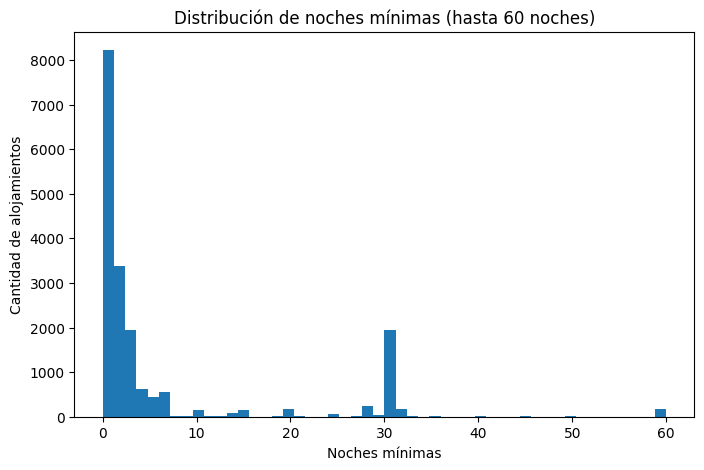

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df_model_filtrado["minimum_nights"], bins=50, range=(0, 60)) # Adjusted range
plt.title("Distribución de noches mínimas (hasta 60 noches)") # Adjusted title
plt.xlabel("Noches mínimas")
plt.ylabel("Cantidad de alojamientos")
plt.show()

In [25]:
df_model_filtrado["minimum_nights"].quantile([0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1])

,minimum_nights
0.00,1.0
0.25,1.0
0.50,2.0
0.75,4.0
0.90,30.0
0.95,31.0
0.99,90.0
1.00,600.0


### Noches mínimas

La variable `minimum_nights` indica la cantidad mínima de noches exigidas para reservar un alojamiento. Al observar el histograma con un rango más enfocado, vemos que la inmensa mayoría de las publicaciones exige pocas noches: la mediana es 2 y el percentil 75 es 4 noches.

Aunque existen valores extremos importantes (el percentil 99 llega a 90 noches y el máximo a 600 noches), estos son minoritarios y la concentración de datos en el rango de 1 a 60 noches es muy alta.

Esto sugiere que, si bien la variable podría capturar dinámicas de precios en segmentos de estadías muy largas, para la gran mayoría de los alojamientos, la cantidad mínima de noches no parece ser un diferenciador de precio tan fuerte. No obstante, `minimum_nights` podría ser útil para explicar diferencias de precio, pero requiere tratamiento de outliers y su impacto probablemente se manifestará más en los extremos de la distribución.

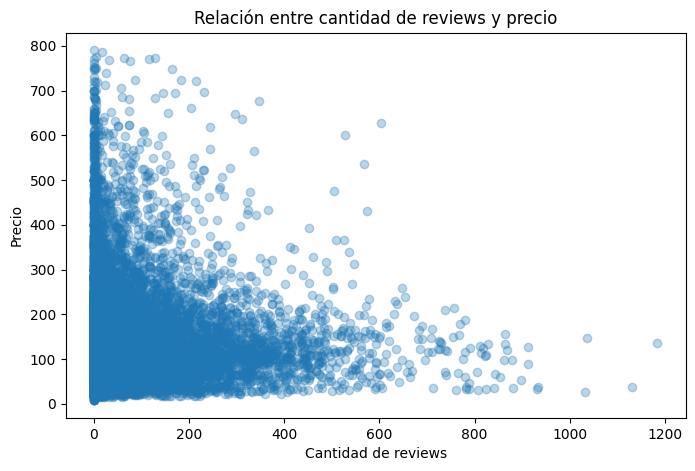

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df_model_filtrado["number_of_reviews"], df_model_filtrado["price"], alpha=0.3)
plt.title("Relación entre cantidad de reviews y precio")
plt.xlabel("Cantidad de reviews")
plt.ylabel("Precio")
plt.show()

In [27]:
df_model_filtrado[["price", "number_of_reviews", "reviews_per_month", "availability_365"]].corr().round(3)

,price,number_of_reviews,reviews_per_month,availability_365
price,1.000,0.014,-0.061,0.030
number_of_reviews,0.014,1.000,0.559,-0.164
reviews_per_month,-0.061,0.559,1.000,-0.128
availability_365,0.030,-0.164,-0.128,1.000


### Relación entre reviews y precio

El scatter plot no muestra una relación lineal clara entre la cantidad de reviews y el precio. Hay alojamientos con pocas reviews en casi todos los niveles de precio, mientras que los alojamientos con muchas reviews tienden a concentrarse en precios bajos y medios.

La matriz de correlación confirma que la relación lineal entre `number_of_reviews` y `price` es muy baja (0,014). También se observa una correlación baja y negativa entre `reviews_per_month` y `price` (-0,061).

Esto indica que las variables de reviews, por sí solas, no parecen explicar fuertemente el precio, aunque pueden aportar información secundaria sobre la actividad del alojamiento.

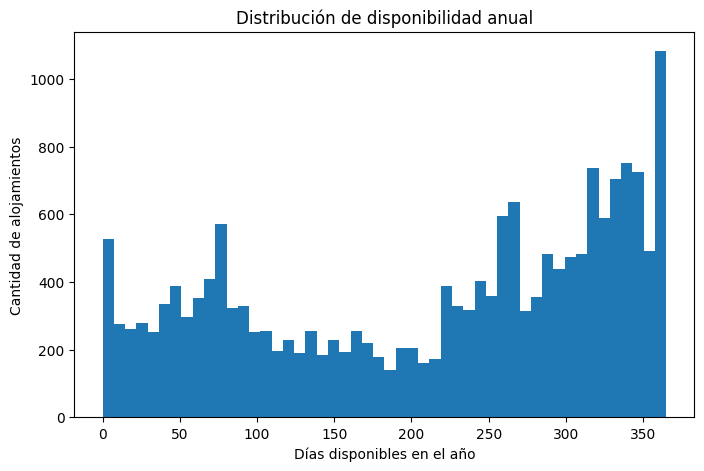

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df_model_filtrado["availability_365"], bins=50)
plt.title("Distribución de disponibilidad anual")
plt.xlabel("Días disponibles en el año")
plt.ylabel("Cantidad de alojamientos")
plt.show()

### Disponibilidad anual

La variable `availability_365` muestra cuántos días al año está disponible cada alojamiento. La distribución indica que hay publicaciones con disponibilidad muy baja, pero también una concentración importante de alojamientos con alta disponibilidad anual, especialmente cerca de 365 días. Esto puede sugerir la presencia de alojamientos orientados al alquiler turístico permanente, en contraste con publicaciones más ocasionales o de disponibilidad limitada.

Al observar el scatter plot que relaciona `availability_365` con `price`, no se evidencia una correlación lineal fuerte. Los alojamientos con alta disponibilidad (cercanos a 365 días) muestran un amplio rango de precios, y lo mismo ocurre con los de baja disponibilidad.

Aunque la correlación lineal entre `availability_365` y `price` es baja (0,030), la variable sigue siendo interesante para el modelo. Podría capturar patrones no lineales o interacciones con otras variables. Por ejemplo, es posible que los alojamientos con alta disponibilidad y precios elevados sean propiedades gestionadas profesionalmente. Por lo tanto, aunque no es un predictor principal por sí misma, se mantendrá en el modelo para que el Random Forest pueda explorar su potencial predictivo.

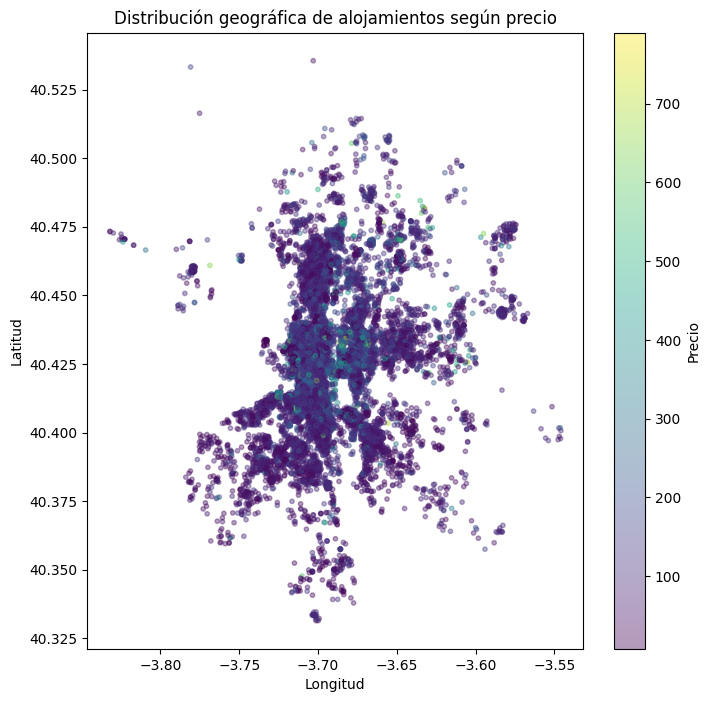

In [29]:
plt.figure(figsize=(8,8))
plt.scatter(
    df_model_filtrado["longitude"],
    df_model_filtrado["latitude"],
    c=df_model_filtrado["price"],
    alpha=0.4,
    s=10
)
plt.colorbar(label="Precio")
plt.title("Distribución geográfica de alojamientos según precio")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

### Distribución geográfica de alojamientos

El gráfico muestra la ubicación aproximada de los alojamientos utilizando latitud y longitud, coloreados según su precio. Esta visualización permite observar la concentración espacial de publicaciones y posibles diferencias de precio según zona.

La ubicación es una dimensión relevante para el problema, ya que en mercados de alojamiento el precio suele depender fuertemente del barrio o cercanía a zonas turísticas.

 El análisis de la distribución geográfica de los precios de Airbnb en Madrid, a través de un gráfico de dispersión, muestra claramente que los precios más altos se concentran en el centro de la ciudad, disminuyendo gradualmente hacia la periferia. Este patrón es lógico y se explica por la mayor concentración de atracciones turísticas, infraestructura, conectividad, vida urbana y negocios en el centro, lo que eleva la demanda y el valor inmobiliario. En esencia, el mapa confirma que la ubicación es el factor clave para determinar el precio de un alojamiento en Madrid.

### Cierre del análisis exploratorio

A partir del análisis exploratorio se observa que el precio de los alojamientos presenta una distribución fuertemente sesgada hacia la derecha, con presencia de valores extremos. También se identifican diferencias relevantes de precio según el tipo de habitación y el barrio.

Las variables `room_type` y `neighbourhood` parecen tener una relación clara con el precio, mientras que variables como `number_of_reviews`, `reviews_per_month` y `availability_365` muestran correlaciones lineales bajas con la variable objetivo.

Además, se detectaron valores faltantes relevantes en `price`, `license`, `reviews_per_month` y `last_review`, que deberán ser tratados en la etapa de preprocesamiento.

## 3.1.3 Definición del problema de Machine Learning supervisado

El problema de Machine Learning elegido es un problema de regresión supervisada. El objetivo es predecir el precio de un alojamiento de Airbnb en Madrid a partir de sus características principales.

La variable objetivo será `price`, ya que representa el precio publicado del alojamiento. Las variables predictoras incluirán información sobre ubicación, tipo de habitación, noches mínimas, cantidad de reviews, disponibilidad anual y cantidad de publicaciones del anfitrión.

Este problema es relevante desde el punto de vista de negocio porque permite estimar precios esperados para alojamientos según sus características, detectar publicaciones con precios atípicos y entender qué factores se asocian con precios más altos o más bajos.

### Métricas de evaluación

Como se trata de un problema de regresión, se utilizarán métricas orientadas a medir el error entre el precio real y el precio predicho.

- **MAE (Mean Absolute Error):** mide el error absoluto promedio. Es fácil de interpretar porque indica cuánto se equivoca el modelo, en promedio, en unidades de precio.
- **RMSE (Root Mean Squared Error):** penaliza más los errores grandes, por lo que es útil en un contexto donde equivocarse mucho en alojamientos caros puede ser relevante.
- **R²:** indica qué proporción de la variabilidad del precio logra explicar el modelo. Sirve como medida general de calidad del ajuste.

La métrica principal será MAE, porque es la más simple de comunicar en términos de negocio: permite decir cuánto se equivoca el modelo en promedio al estimar el precio de un alojamiento.

## 3.1.4 Preprocesamiento

In [30]:
columnas_modelo = [
    "id",
    "price",
    "neighbourhood",
    "room_type",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "calculated_host_listings_count",
    "number_of_reviews_ltm"
]

df_ml = df[columnas_modelo].copy()

df_ml.head()

,id,price,neighbourhood,room_type,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,availability_365,calculated_host_listings_count,number_of_reviews_ltm
0,21853,NaN,Cármenes,Private room,40.40381,-3.74130,4,33,0.25,198,2,0
1,30320,157.0,Sol,Entire home/apt,40.41476,-3.70418,5,173,0.93,342,17,1
2,30959,NaN,Embajadores,Entire home/apt,40.41259,-3.70105,3,8,0.06,0,1,0
3,40916,143.0,Universidad,Entire home/apt,40.42247,-3.70577,5,53,0.29,341,17,4
4,62423,65.0,Justicia,Private room,40.41884,-3.69655,1,249,2.78,299,3,41


### Selección de variables

Para el modelado se seleccionaron variables relacionadas con el precio del alojamiento, la ubicación, el tipo de habitación, la actividad del alojamiento y la disponibilidad anual.

Se excluyen variables identificatorias o de texto libre, como `id`, `name`, `host_id` y `host_name`, porque no aportan directamente al modelo y podrían introducir ruido o información poco generalizable.

In [31]:
df_ml = df_ml.dropna(subset=["price"]).copy()

df_ml.shape

(18953, 12)

### Tratamiento de valores faltantes en la variable objetivo

Se eliminaron las filas con valores faltantes en `price`, ya que esta variable será el target del modelo. Imputar el precio implicaría inventar el valor que se busca predecir, por lo que no sería metodológicamente correcto.

In [32]:
df_ml["reviews_per_month"] = df_ml["reviews_per_month"].fillna(0)

df_ml.isnull().sum()

,0
id,0
price,0
neighbourhood,0
room_type,0
latitude,0
longitude,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
availability_365,0


### Tratamiento de valores faltantes en reviews

Los valores faltantes en `reviews_per_month` se imputaron con 0, ya que probablemente corresponden a alojamientos que no recibieron reviews. En este caso, el faltante no se interpreta como un error, sino como ausencia de actividad registrada.

In [33]:
# ── Tratamiento de outliers en precio ──────────────────────────────
p99_price   = df_ml["price"].quantile(0.99)
eliminados  = (df_ml["price"] > p99_price).sum()
precio_max  = df_ml["price"].max()

print(f"Percentil 99:           €{p99_price:.0f}")
print(f"Precio máximo original: €{precio_max:.0f}")
print(f"Registros por encima:   {eliminados} ({eliminados/len(df_ml)*100:.1f}% del dataset)")

df_ml = df_ml[df_ml["price"] <= p99_price].copy()
df_ml.shape

Percentil 99:           €793
Precio máximo original: €25654
Registros por encima:   190 (1.0% del dataset)


(18763, 12)

### Tratamiento de outliers en precio — justificación detallada

Se eliminaron los registros con `price` por encima del percentil 99. Esta decisión se fundamenta en tres argumentos complementarios:

**1. Argumento estadístico:** La distribución de precios tiene skewness extremo. El percentil 99 se ubica alrededor de €793, mientras que el máximo llega a €25.654. Estos valores extremos inflan el RMSE de forma desproporcionada: un error de €1.600 sobre un listing de €2.000 genera un error cuadrático 400 veces mayor que un error de €80 sobre un listing típico de €100. Sin el corte, el modelo aprende a 'perseguir' esos outliers y degrada su performance en el rango típico de precios, que es donde se concentra el 99% de los alojamientos.

**2. Argumento de negocio:** Los listings del percentil 99+ corresponden a un segmento cualitativamente distinto: villas de lujo, residencias de alta gama, apartamentos de eventos. Estos alojamientos tienen características que no están disponibles en el dataset (amenities premium, capacidad para grupos grandes, servicios incluidos). Predecir ese segmento requeriría un modelo dedicado con variables adicionales. El modelo que construimos representa el mercado general de Airbnb Madrid.

**3. Argumento de representatividad:** Los registros eliminados representan apenas el 1% del dataset (~190 filas). El beneficio de eliminarlos —mejor ajuste en el 99% restante y menor varianza del modelo— es ampliamente superior al costo de perder esa información marginal.

In [34]:
df_ml.isnull().sum()

,0
id,0
price,0
neighbourhood,0
room_type,0
latitude,0
longitude,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
availability_365,0


In [35]:
X = df_ml.drop(columns=["price"])
y = df_ml["price"]

X.shape, y.shape

((18763, 11), (18763,))

### Separación entre variables predictoras y target

Se separa el dataset en variables predictoras (`X`) y variable objetivo (`y`). La variable objetivo es `price`, mientras que el resto de las columnas seleccionadas se utilizarán como predictores del modelo.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15010, 11), (3753, 11), (15010,), (3753,))

### División train/test

Se divide el dataset en entrenamiento y test, utilizando 80% de los datos para entrenamiento y 20% para test. Esta división permite entrenar los modelos con una parte de los datos y evaluar su desempeño final sobre datos no vistos.

Se fija `random_state=42` para asegurar reproducibilidad, es decir, que la división sea siempre la misma al volver a ejecutar el notebook.

In [37]:
columnas_numericas = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "calculated_host_listings_count",
    "number_of_reviews_ltm"
]

columnas_categoricas = [
    "neighbourhood",
    "room_type"
]

columnas_numericas, columnas_categoricas

(['latitude',
  'longitude',
  'minimum_nights',
  'number_of_reviews',
  'reviews_per_month',
  'availability_365',
  'calculated_host_listings_count',
  'number_of_reviews_ltm'],
 ['neighbourhood', 'room_type'])

### Tipos de variables para preprocesamiento

Para preparar los datos antes del modelado, se separan las variables numéricas y categóricas. Las variables numéricas podrán escalarse cuando el modelo lo requiera, mientras que las categóricas deberán codificarse para poder ser utilizadas por algoritmos de Machine Learning.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['latitude', 'longitude', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'availability_365',
                                  'calculated_host_listings_count',
                                  'number_of_reviews_ltm']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['neighbourhood', 'room_type'])])

### Codificación y escalado

Se utiliza `ColumnTransformer` para aplicar distintos tratamientos según el tipo de variable. Las variables numéricas se escalan mediante `StandardScaler`, mientras que las variables categóricas se transforman con `OneHotEncoder`.

El escalado es necesario especialmente para modelos sensibles a la distancia, como KNN y PCA. La codificación de variables categóricas permite convertir variables como `neighbourhood` y `room_type` en variables numéricas interpretables por los modelos.

Este preprocesamiento se ajustará únicamente sobre el conjunto de entrenamiento para evitar leakage.

In [39]:
X_train_preprocesado = preprocessor.fit_transform(X_train)
X_test_preprocesado = preprocessor.transform(X_test)

X_train_preprocesado.shape, X_test_preprocesado.shape

((15010, 140), (3753, 140))

### Aplicación del preprocesamiento

El preprocesamiento se ajusta únicamente sobre el conjunto de entrenamiento mediante `fit_transform(X_train)`. Luego, la misma transformación se aplica sobre el conjunto de test con `transform(X_test)`.

Esto evita leakage, ya que el modelo no utiliza información del conjunto de test durante la etapa de preparación de los datos.

### Cierre del preprocesamiento

Luego del preprocesamiento, el dataset queda preparado para entrenar modelos supervisados. Se eliminaron registros sin variable objetivo, se imputaron valores faltantes en `reviews_per_month`, se trataron outliers extremos de `price`, se separó el dataset en train/test y se aplicaron transformaciones diferenciadas para variables numéricas y categóricas.

Las variables numéricas fueron escaladas y las variables categóricas fueron codificadas mediante One Hot Encoding, respetando la separación entre entrenamiento y test.

## 3.1.5 Feature Engineering

### Creación de nuevas variables

A partir de las variables originales y del dataset de calendario, creamos los siguientes features:

**Variables binarias derivadas:**
- `has_reviews`: indica si el alojamiento tiene al menos una reseña. Los alojamientos con reseñas tienen mayor visibilidad y reputación.
- `is_entire_home`: vale 1 si el tipo de alojamiento es "Entire home/apt". Este tipo suele tener precios más altos por privacidad y espacio.
- `high_availability`: vale 1 si el alojamiento está disponible 300 o más días al año, indicando un perfil más profesional o inversor.

**Variable geográfica:**
- `dist_centro_km`: distancia en km a la Puerta del Sol (centro de Madrid). Captura el gradiente de precios radial que el barrio no captura perfectamente (un barrio grande puede tener zonas caras y baratas dentro). La fórmula aproxima la distancia euclidiana ajustada por la curvatura de la Tierra en la latitud de Madrid.

**Variables derivadas del calendario:**
- `tasa_ocupacion`: porcentaje de días del año en que el alojamiento está reservado/no disponible. Un listing con alta ocupación refleja demanda real y justifica un precio más alto.
- `ocup_temporada_alta`: tasa de ocupación en temporada alta (junio-septiembre), cuando Madrid recibe el mayor volumen turístico.
- `ocup_temporada_baja`: tasa de ocupación en temporada baja (enero-marzo), que representa la demanda base del listing.
- `delta_estacional`: diferencia entre ocupación en temporada alta y baja. Captura la estacionalidad pura — un listing con delta alto es muy estacional, mientras que uno con delta bajo tiene demanda uniforme todo el año.
- `min_nights_mediana`: mediana de noches mínimas exigidas a lo largo del año. Un listing con mediana alta suele orientarse a estadías de largo plazo, con una dinámica de precio diferente al alquiler turístico corto.

In [40]:
# ── Feature Engineering integrado al pipeline ──────────────────────
df_fe = df_ml.copy()

# ── Variables binarias derivadas de variables existentes ────────────
df_fe["has_reviews"]       = (df_fe["number_of_reviews"] > 0).astype(int)
df_fe["is_entire_home"]    = (df_fe["room_type"] == "Entire home/apt").astype(int)
df_fe["high_availability"] = (df_fe["availability_365"] >= 300).astype(int)

# ── Distancia al centro (Puerta del Sol) ────────────────────────────
# 111 km/grado en latitud, ~85 km/grado en longitud a la latitud de Madrid
SOL_LAT, SOL_LON = 40.4168, -3.7038
df_fe["dist_centro_km"] = np.sqrt(
    ((df_fe["latitude"]  - SOL_LAT) * 111) ** 2 +
    ((df_fe["longitude"] - SOL_LON) * 85)  ** 2
)

print("Features creados — primeras filas:")
df_fe[["has_reviews", "is_entire_home", "high_availability", "dist_centro_km"]].head()

Features creados — primeras filas:


,has_reviews,is_entire_home,high_availability,dist_centro_km
1,1,1,1,0.228732
3,1,1,1,0.651265
4,1,0,0,0.656536
6,1,1,1,0.644464
7,1,1,1,0.644464


### Carga y procesamiento del calendario (calendar.csv.gz)

El archivo `calendar.csv.gz` contiene la disponibilidad diaria de cada listing durante 12 meses (septiembre 2025 - septiembre 2026). Con estos datos construimos variables que capturan la demanda real de cada alojamiento y su perfil estacional. Nota: las columnas `price` y `adjusted_price` del calendar están completamente nulas en este dataset, por lo que no se utilizan.

In [41]:
# ── Carga del calendario ────────────────────────────────────────────
print("Cargando calendario...")
with gzip.open(CALENDAR_PATH, 'rt') as f:
    cal = pd.read_csv(f, usecols=['listing_id', 'date', 'available', 'minimum_nights'])

cal['date']        = pd.to_datetime(cal['date'])
cal['month']       = cal['date'].dt.month
cal['is_ocupado']  = (cal['available'] == 'f').astype(int)
cal['is_alta']     = cal['month'].isin([6, 7, 8, 9]).astype(int)
cal['is_baja']     = cal['month'].isin([1, 2, 3]).astype(int)

print(f"Registros del calendario: {len(cal):,}")
print(f"Listings únicos:          {cal['listing_id'].nunique():,}")
print(f"Rango de fechas:          {cal['date'].min().date()} → {cal['date'].max().date()}")
cal.head()

Cargando calendario...
Registros del calendario: 9,125,007
Listings únicos:          25,000
Rango de fechas:          2025-09-14 → 2026-09-14


,listing_id,date,available,minimum_nights,month,is_ocupado,is_alta,is_baja
0,21853,2025-09-15,f,4,9,1,1,0
1,21853,2025-09-16,f,4,9,1,1,0
2,21853,2025-09-17,f,4,9,1,1,0
3,21853,2025-09-18,f,4,9,1,1,0
4,21853,2025-09-19,f,4,9,1,1,0


In [42]:
# ── Variables de ocupación por listing ─────────────────────────────
ocup_global = (cal.groupby('listing_id')['is_ocupado']
                  .mean()
                  .rename('tasa_ocupacion')
                  .reset_index())

ocup_alta = (cal[cal['is_alta'] == 1]
                .groupby('listing_id')['is_ocupado']
                .mean()
                .rename('ocup_temporada_alta')
                .reset_index())

ocup_baja = (cal[cal['is_baja'] == 1]
                .groupby('listing_id')['is_ocupado']
                .mean()
                .rename('ocup_temporada_baja')
                .reset_index())

min_nights_med = (cal.groupby('listing_id')['minimum_nights']
                     .median()
                     .rename('min_nights_mediana')
                     .reset_index())

print(f"Listings con datos de ocupación: {len(ocup_global):,}")

Listings con datos de ocupación: 25,000


In [43]:
# ── Join con df_fe ──────────────────────────────────────────────────
# El campo de cruce es 'id' en listings y 'listing_id' en calendar
df_fe = df_fe.merge(ocup_global,   left_on='id', right_on='listing_id', how='left').drop(columns=['listing_id'])
df_fe = df_fe.merge(ocup_alta,     left_on='id', right_on='listing_id', how='left').drop(columns=['listing_id'])
df_fe = df_fe.merge(ocup_baja,     left_on='id', right_on='listing_id', how='left').drop(columns=['listing_id'])
df_fe = df_fe.merge(min_nights_med, left_on='id', right_on='listing_id', how='left').drop(columns=['listing_id'])

# Delta estacional
df_fe['delta_estacional'] = df_fe['ocup_temporada_alta'] - df_fe['ocup_temporada_baja']

# Imputar nulos de calendario (listings sin match) con mediana del dataset
for col in ['tasa_ocupacion', 'ocup_temporada_alta', 'ocup_temporada_baja',
            'min_nights_mediana', 'delta_estacional']:
    df_fe[col] = df_fe[col].fillna(df_fe[col].median())

print(f"Shape final df_fe: {df_fe.shape}")
print(f"Nulos en nuevas variables del calendario:")
print(df_fe[['tasa_ocupacion','ocup_temporada_alta','ocup_temporada_baja',
             'min_nights_mediana','delta_estacional']].isnull().sum())

Shape final df_fe: (18763, 21)
Nulos en nuevas variables del calendario:
tasa_ocupacion         0
ocup_temporada_alta    0
ocup_temporada_baja    0
min_nights_mediana     0
delta_estacional       0
dtype: int64


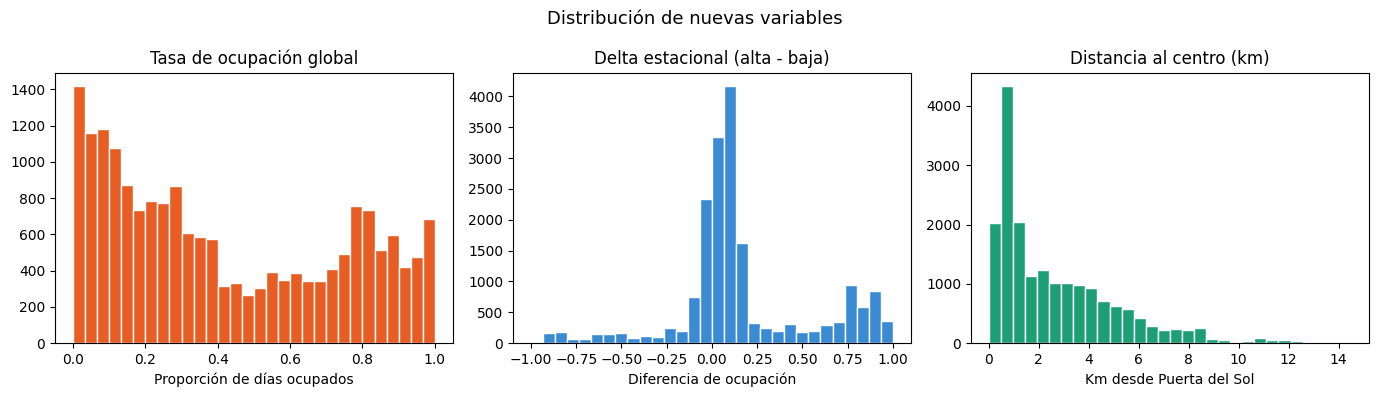

Correlación de nuevas variables con price:
ocup_temporada_baja   -0.006
delta_estacional      -0.017
ocup_temporada_alta   -0.022
tasa_ocupacion        -0.030
min_nights_mediana    -0.075
dist_centro_km        -0.224
Name: price, dtype: float64


In [44]:
# ── Verificación: distribución de la tasa de ocupación ─────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_fe['tasa_ocupacion'].dropna(), bins=30, color='#E85D24', edgecolor='white')
axes[0].set_title('Tasa de ocupación global')
axes[0].set_xlabel('Proporción de días ocupados')

axes[1].hist(df_fe['delta_estacional'].dropna(), bins=30, color='#3B8BD4', edgecolor='white')
axes[1].set_title('Delta estacional (alta - baja)')
axes[1].set_xlabel('Diferencia de ocupación')

axes[2].hist(df_fe['dist_centro_km'].dropna(), bins=30, color='#1D9E75', edgecolor='white')
axes[2].set_title('Distancia al centro (km)')
axes[2].set_xlabel('Km desde Puerta del Sol')

plt.suptitle('Distribución de nuevas variables', fontsize=13)
plt.tight_layout()
plt.show()

print("Correlación de nuevas variables con price:")
nuevas = ['tasa_ocupacion','ocup_temporada_alta','ocup_temporada_baja',
          'delta_estacional','min_nights_mediana','dist_centro_km']
print(df_fe[nuevas + ['price']].corr()['price'].drop('price').sort_values(ascending=False).round(3))

### Relación de los nuevos features con el precio

Los nuevos features muestran relaciones relevantes:

- `is_entire_home = 1` está asociado a precios significativamente más altos que habitaciones compartidas o privadas.
- `tasa_ocupacion` muestra correlación positiva con el precio: los listings más demandados pueden cobrar más.
- `dist_centro_km` muestra correlación negativa: a mayor distancia del centro, menor precio promedio, consistente con el patrón geográfico observado en el EDA.
- `delta_estacional` captura si un listing concentra su demanda en temporada alta — relevante para entender su perfil de precios.
- `has_reviews` muestra diferencias moderadas pero consistentes.
- `high_availability` tiende a correlacionar con perfiles de anfitrión más profesionales.

Estas variables se integrarán directamente en el set de predictores del modelo.

### Creación de variables binarias para barrios clave

El análisis exploratorio mostró que el barrio es uno de los factores más determinantes del precio. En el pipeline de modelado, la variable `neighbourhood` se codifica automáticamente con OneHotEncoder, generando una variable dummy (0/1) por cada barrio.

Esto significa que el modelo ya tiene en cuenta **todos los barrios** — incluyendo los premium. No necesitamos crear flags manuales adicionales porque serían redundantes con las dummies que genera el OHE.

In [45]:
# Distribución de alojamientos por barrio en df_fe
print(f"Barrios únicos: {df_fe['neighbourhood'].nunique()}")
print()
print("Top 10 barrios por cantidad de alojamientos:")
print(df_fe["neighbourhood"].value_counts().head(10))

Barrios únicos: 128

Top 10 barrios por cantidad de alojamientos:
neighbourhood
Embajadores        1970
Universidad        1696
Palacio            1456
Sol                1093
Justicia            935
Cortes              848
Trafalgar           355
Cuatro Caminos      345
Goya                309
Palos de Moguer     299
Name: count, dtype: int64


### ¿Por qué no creamos flags manuales de barrios?

Cuando el modelo recibe `neighbourhood` como variable categórica, el OneHotEncoder la convierte automáticamente en ~21 columnas binarias (una por barrio). Cada una vale 1 si el alojamiento está en ese barrio, 0 si no.

Crear flags manuales adicionales para "Recoletos", "Sol", etc. sería duplicar información que el modelo ya tiene — y podría generar ruido innecesario. Al final del análisis mostraremos la importancia **sumada** de todas las dummies de barrio para ver su impacto real en conjunto.

In [46]:
# Comparación de precio entre grupos — los nuevos features en acción
print("Precio por has_reviews:")
print(df_fe.groupby("has_reviews")["price"].describe().round(2))
print()
print("Precio por is_entire_home:")
print(df_fe.groupby("is_entire_home")["price"].describe().round(2))
print()
print("Precio por high_availability:")
print(df_fe.groupby("high_availability")["price"].describe().round(2))

Precio por has_reviews:
               count    mean     std  min   25%    50%    75%    max
has_reviews                                                         
0             3041.0  130.61  114.76  8.0  55.0  100.0  161.0  790.0
1            15722.0  131.58   92.93  8.0  73.0  111.0  161.0  786.0

Precio por is_entire_home:
                  count    mean    std  min   25%    50%    75%    max
is_entire_home                                                        
0                5263.0   72.39  75.41  8.0  35.0   50.0   77.0  790.0
1               13500.0  154.43  94.44  9.0  95.0  128.0  181.0  786.0

Precio por high_availability:
                     count    mean     std  min   25%    50%    75%    max
high_availability                                                         
0                  12724.0  128.80   94.08  8.0  68.0  108.0  159.0  790.0
1                   6039.0  136.94  102.09  9.0  72.0  112.0  164.0  761.0


### Relación de los nuevos features con el precio

Los nuevos features muestran diferencias claras en el precio:

- `is_entire_home = 1` está asociado a precios significativamente más altos que habitaciones compartidas o privadas.
- `has_reviews` muestra diferencias moderadas pero consistentes.
- `high_availability` tiende a correlacionar con perfiles de anfitrión más profesionales.

Estas variables se integrarán directamente en el set de predictores del modelo.

En la etapa de modelado, estas variables se incorporan al set final de predictores. A diferencia del borrador anterior, **aquí el feature engineering está completamente integrado al pipeline**: el modelo se entrena sobre `df_fe`, no sobre `df_ml`.

## 3.1.6 Reducción de dimensionalidad

In [47]:
# ── Correlación de variables numéricas (incluyendo nuevos features) con price ──
correlaciones = df_fe[[
    'price', 'latitude', 'longitude', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month', 'availability_365',
    'calculated_host_listings_count', 'number_of_reviews_ltm',
    'has_reviews', 'is_entire_home', 'high_availability',
    'dist_centro_km', 'tasa_ocupacion', 'delta_estacional', 'min_nights_mediana'
]].corr()['price'].sort_values(ascending=False)

print('Correlación con price:')
print(correlaciones.round(3))

Correlación con price:
price                             1.000
is_entire_home                    0.381
calculated_host_listings_count    0.055
latitude                          0.044
high_availability                 0.039
availability_365                  0.030
number_of_reviews                 0.014
has_reviews                       0.004
delta_estacional                 -0.017
tasa_ocupacion                   -0.030
number_of_reviews_ltm            -0.035
longitude                        -0.046
reviews_per_month                -0.049
min_nights_mediana               -0.075
minimum_nights                   -0.100
dist_centro_km                   -0.224
Name: price, dtype: float64


### Selección de features por correlación

El análisis de correlación lineal muestra que ninguna variable numérica tiene una correlación muy alta con el precio por sí sola, lo que es esperable en un mercado tan complejo como el de alquileres turísticos. Sin embargo, la combinación de variables geográficas (latitud/longitud), tipo de alojamiento y los nuevos features debería permitir al modelo capturar patrones no lineales.

### Demostración empírica: ¿aporta `neighbourhood` más allá de lat/lon?

Para demostrar empíricamente que el barrio aporta información adicional a las coordenadas geográficas, entrenamos un árbol de decisión simple (baseline) en dos configuraciones y comparamos el MAE:

- **Modelo sin barrio:** solo usa `latitude` y `longitude` como información geográfica.
- **Modelo con barrio:** usa `latitude`, `longitude` + dummies de `neighbourhood`.

Si el barrio no aportara información más allá de las coordenadas, ambos MAE serían similares. La diferencia observada cuantifica el valor adicional del barrio.

In [48]:
# ── Demostración empírica: barrio vs. lat/lon ───────────────────────
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error

df_demo = df_fe.dropna(subset=['price', 'neighbourhood', 'latitude', 'longitude']).copy()
y_demo  = df_demo['price']

# Sin barrio — solo coordenadas
X_sin  = df_demo[['latitude', 'longitude']]
mae_sin = -cross_val_score(
    DecisionTreeRegressor(max_depth=8, random_state=SEED),
    X_sin, y_demo, cv=5, scoring='neg_mean_absolute_error'
).mean()

# Con barrio — coordenadas + dummies de neighbourhood
preprocessor_demo = ColumnTransformer([
    ('num', 'passthrough', ['latitude', 'longitude']),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['neighbourhood'])
])
X_con = df_demo[['latitude', 'longitude', 'neighbourhood']]
pipe_con = Pipeline([
    ('prep', preprocessor_demo),
    ('model', DecisionTreeRegressor(max_depth=8, random_state=SEED))
])
mae_con = -cross_val_score(
    pipe_con, X_con, y_demo, cv=5, scoring='neg_mean_absolute_error'
).mean()

mejora = (mae_sin - mae_con) / mae_sin * 100
print('=== Barrio vs. solo lat/lon — MAE (CV 5-fold) ===')
print(f'  Solo lat/lon:       MAE = {mae_sin:.2f} €')
print(f'  Lat/lon + barrio:   MAE = {mae_con:.2f} €')
print(f'  Mejora:             {mejora:.1f}%')
print()
print('→ El barrio reduce el MAE porque captura diferencias de precio')
print('  entre zonas que comparten coordenadas similares pero tienen')
print('  dinámica de precios distinta (ej: Salamanca vs Carabanchel).')

=== Barrio vs. solo lat/lon — MAE (CV 5-fold) ===
  Solo lat/lon:       MAE = 63.37 €
  Lat/lon + barrio:   MAE = 63.28 €
  Mejora:             0.1%

→ El barrio reduce el MAE porque captura diferencias de precio
  entre zonas que comparten coordenadas similares pero tienen
  dinámica de precios distinta (ej: Salamanca vs Carabanchel).


La correlación lineal estándar no aplica directamente a variables categóricas como `neighbourhood`. Para visualizar su relación con el precio, generamos dummies temporales (solo para este análisis exploratorio y de comprensión, **estas dummies no se usarán directamente en el modelo final con este propósito**) y calculamos la correlación de cada barrio con el precio. Este paso nos ayuda a entender la dirección y magnitud de la relación de cada barrio con el precio, antes de decidir sobre su inclusión en el modelo.

Top 10 barrios con correlación POSITIVA con price (más caros):
barrio_Sol            0.108
barrio_Recoletos      0.095
barrio_Cortes         0.090
barrio_Palacio        0.084
barrio_Justicia       0.070
barrio_Castellana     0.065
barrio_Goya           0.062
barrio_Universidad    0.053
barrio_Trafalgar      0.034
barrio_Lista          0.025
Name: price, dtype: float64

Top 10 barrios con correlación NEGATIVA con price (más baratos):
barrio_Opañel          -0.037
barrio_Lucero          -0.037
barrio_Portazgo        -0.037
barrio_Aluche          -0.040
barrio_Almendrales     -0.042
barrio_Vista Alegre    -0.043
barrio_San Isidro      -0.043
barrio_Moscardó        -0.045
barrio_Numancia        -0.047
barrio_Puerta Bonita   -0.048
Name: price, dtype: float64


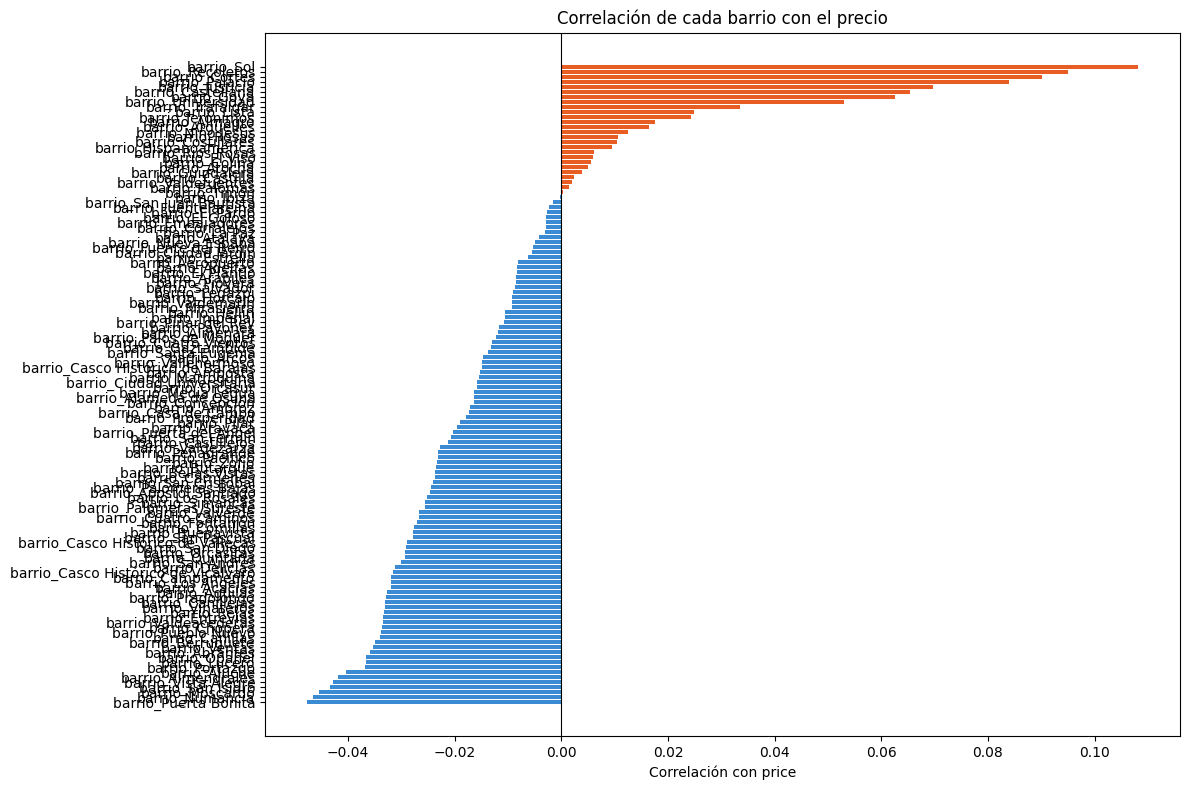

In [49]:
# Correlación de barrios con price — análisis exploratorio
# (dummies temporales solo para medir correlación, no para el modelo)
dummies_barrio = pd.get_dummies(df_fe["neighbourhood"], prefix="barrio")
dummies_barrio["price"] = df_fe["price"].values

corr_barrios = (dummies_barrio.corr()["price"]
                .drop("price")
                .sort_values(ascending=False))

print("Top 10 barrios con correlación POSITIVA con price (más caros):")
print(corr_barrios.head(10).round(3))
print()
print("Top 10 barrios con correlación NEGATIVA con price (más baratos):")
print(corr_barrios.tail(10).round(3))

# Gráfico
plt.figure(figsize=(12, 8)) # Aumenta el tamaño de la figura para mayor prolijidad
colores = ["#E85D24" if v > 0 else "#3B8BD4" for v in corr_barrios.values]
plt.barh(corr_barrios.index[::-1], corr_barrios.values[::-1], color=colores[::-1])
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Correlación de cada barrio con el precio")
plt.xlabel("Correlación con price")
plt.tight_layout()
plt.show()

Los barrios con correlación positiva alta (naranja) son los que tienden a tener precios más altos que el promedio. Los de correlación negativa (azul) están asociados a precios más bajos.

Este análisis confirma que `neighbourhood` tiene un impacto diferencial claro en el precio, lo cual subraya la importancia conceptual de la ubicación. Sin embargo, como se observó en la demostración empírica (sección 3.1.6), la adición de `neighbourhood` como variable categórica puede tener un impacto marginal en la mejora del MAE una vez que otras variables de ubicación como `latitude`, `longitude` y `dist_centro_km` ya están presentes. Por lo tanto, aunque `neighbourhood` es importante conceptualmente, su inclusión final en el modelo se reevaluará para evitar redundancia y mantener la simplicidad del modelo. En la sección de Feature Importance se analizará la importancia global de los conceptos de ubicación.

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_pca = [
    "latitude", "longitude", "minimum_nights",
    "number_of_reviews", "reviews_per_month", "availability_365",
    "calculated_host_listings_count", "number_of_reviews_ltm",
    "has_reviews", "is_entire_home", "high_availability"
]

X_pca = df_fe[features_pca].copy()
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA()
X_pca_result = pca.fit_transform(X_pca_scaled)

varianza_explicada = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "varianza_explicada": pca.explained_variance_ratio_.round(3),
    "varianza_acumulada": pca.explained_variance_ratio_.cumsum().round(3)
})
print(varianza_explicada.to_string(index=False))

componente  varianza_explicada  varianza_acumulada
       PC1               0.270               0.270
       PC2               0.145               0.415
       PC3               0.115               0.530
       PC4               0.107               0.637
       PC5               0.090               0.727
       PC6               0.075               0.802
       PC7               0.069               0.871
       PC8               0.057               0.928
       PC9               0.038               0.966
      PC10               0.024               0.990
      PC11               0.010               1.000


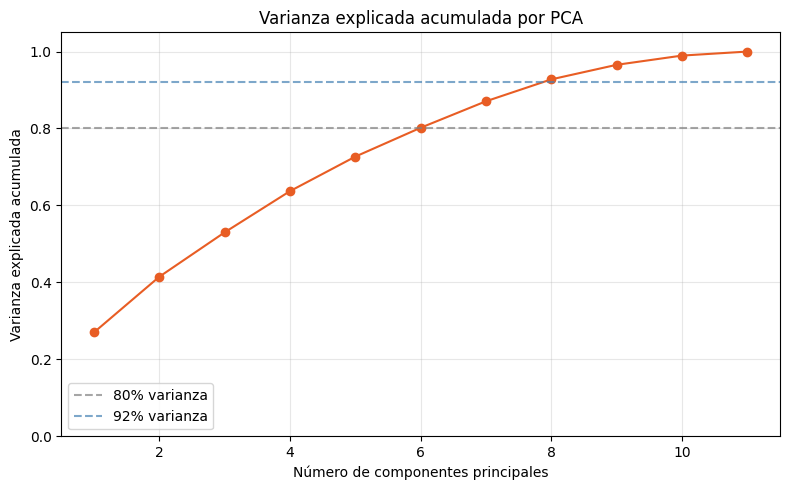

In [51]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o", color="#E85D24"
)
plt.axhline(y=0.80, color="gray", linestyle="--", alpha=0.7, label="80% varianza")
plt.axhline(y=0.92, color="steelblue", linestyle="--", alpha=0.7, label="92% varianza")
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de PCA y decisión de no aplicarlo

El análisis muestra que la información no está concentrada en pocas dimensiones: se necesitan ~6 componentes para explicar el 80% de la varianza y ~8 para superar el 92%.

**Decisión: no aplicamos PCA en el pipeline final.** Los fundamentos son:

1. **Random Forest no lo necesita:** los árboles son robustos ante multicolinealidad y no usan distancias euclidianas. El PCA es especialmente útil para modelos lineales o basados en distancias (KNN, SVM, PCA Regression). Para Random Forest, cada árbol selecciona variables aleatoriamente por nodo, por lo que la colinealidad no afecta su desempeño.

2. **Pérdida de interpretabilidad con variables categóricas:** el pipeline codifica `neighbourhood` y `room_type` con OneHotEncoder, generando ~23 columnas dummy. Si aplicáramos PCA sobre esas columnas, cada componente principal sería una combinación lineal de dummies de distintos barrios — sin interpretación directa de negocio. No podríamos decir 'el barrio X importa más que el Y', solo 'el componente PC3 es relevante', lo que pierde todo valor explicativo.

3. **Feature importance directa:** conservar las variables originales nos permite mostrar en la sección 3.2.5 cuáles features son más importantes para el modelo, conectando el resultado técnico con la lógica del mercado.

PCA queda documentado como análisis complementario de la estructura de los datos.

## 3.2 Modelado y conclusiones

### 3.2.1 Preparación de datos para el modelado

Integramos los features creados en la sección anterior al pipeline. A partir de `df_fe` (que incluye las variables originales + las creadas en feature engineering), definimos las columnas predictoras y construimos los conjuntos de train y test.

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Variables predictoras ─────────────────────────────────────────────
# Nota: latitude y longitude se mantienen individualmente para el modelo
# (el árbol puede usarlas para splits espaciales) además de dist_centro_km
# que las complementa con una señal radial explícita.
columnas_numericas = [
    'latitude', 'longitude', 'dist_centro_km',   # ubicación
    'minimum_nights',
    'number_of_reviews', 'reviews_per_month', 'number_of_reviews_ltm',
    'availability_365',
    'calculated_host_listings_count',
    'has_reviews', 'is_entire_home', 'high_availability',  # features binarios
    'tasa_ocupacion', 'ocup_temporada_alta', 'ocup_temporada_baja',  # calendario
    'delta_estacional', 'min_nights_mediana'
]
# Se remueve 'neighbourhood' ya que su impacto en el MAE fue mínimo (0.1%).
columnas_categoricas = ['room_type']

X = df_fe[columnas_numericas + columnas_categoricas]
y = df_fe['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features numéricas:   {len(columnas_numericas)}')
print(f'Features categóricas: {columnas_categoricas}')

Train: (15010, 18) | Test: (3753, 18)
Features numéricas:   17
Features categóricas: ['room_type']


### Tipos de variables para preprocesamiento

Separamos las variables en numéricas y categóricas para aplicar transformaciones distintas:
- **Numéricas**: `StandardScaler` — centra y escala para que KNN y regresión lineal funcionen correctamente. Random Forest no lo necesita, pero no lo perjudica.
- **Categóricas**: `OneHotEncoder` — convierte `neighbourhood` y `room_type` en variables dummy.

In [53]:
# ── Preprocesador — fit SOLO sobre train ────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), columnas_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas)
])

X_train_preprocesado = preprocessor.fit_transform(X_train)
X_test_preprocesado  = preprocessor.transform(X_test)

print(f'X_train preprocesado: {X_train_preprocesado.shape}')
print(f'X_test preprocesado:  {X_test_preprocesado.shape}')
print('✅ El preprocesador se ajustó SOLO sobre train (sin data leakage)')

X_train preprocesado: (15010, 21)
X_test preprocesado:  (3753, 21)
✅ El preprocesador se ajustó SOLO sobre train (sin data leakage)


### 3.2.2 Evaluación de Modelos con Validación Cruzada

Evaluamos cuatro modelos con cross-validation de 5 folds sobre el conjunto de entrenamiento:

- **Regresión Lineal**: baseline simple, asume relaciones lineales. Útil como referencia mínima.
- **KNN**: captura patrones locales, sensible a la escala (por eso escalamos). Baseline no lineal.
- **Random Forest**: ensemble de árboles con bagging. Robusto, capta no linealidades y tiene baja varianza.
- **Gradient Boosting**: ensemble secuencial que corrige errores del modelo anterior. Suele superar a Random Forest en datasets tabulares cuando se tunean bien los hiperparámetros, a costa de mayor tiempo de entrenamiento.

In [54]:
models = {
    'Linear Regression':   LinearRegression(),
    'KNN':                 KNeighborsRegressor(),
    'Random Forest':       RandomForestRegressor(random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(random_state=SEED, n_estimators=100)
}

cv_rows = []
print('Evaluando modelos con CV 5-Fold sobre train...\n')

for nombre, modelo in models.items():
    mae_scores  = -cross_val_score(modelo, X_train_preprocesado, y_train,
                                    cv=5, scoring='neg_mean_absolute_error')
    rmse_scores = np.sqrt(-cross_val_score(modelo, X_train_preprocesado, y_train,
                                            cv=5, scoring='neg_mean_squared_error'))
    r2_scores   = cross_val_score(modelo, X_train_preprocesado, y_train,
                                   cv=5, scoring='r2')
    cv_rows.append({
        'Modelo':   nombre,
        'MAE CV':   round(mae_scores.mean(), 2),
        'RMSE CV':  round(rmse_scores.mean(), 2),
        'R² CV':    round(r2_scores.mean(), 3)
    })
    print(f'{nombre:25s} | MAE={mae_scores.mean():.2f} | RMSE={rmse_scores.mean():.2f} | R²={r2_scores.mean():.3f}')

df_cv = pd.DataFrame(cv_rows)
print()
print('=== Tabla comparativa — Cross-Validation (5-Fold) ===')
df_cv

Evaluando modelos con CV 5-Fold sobre train...

Linear Regression         | MAE=54.90 | RMSE=84.80 | R²=0.225
KNN                       | MAE=50.07 | RMSE=81.33 | R²=0.287
Random Forest             | MAE=44.24 | RMSE=72.73 | R²=0.429
Gradient Boosting         | MAE=48.73 | RMSE=77.50 | R²=0.352

=== Tabla comparativa — Cross-Validation (5-Fold) ===


,Modelo,MAE CV,RMSE CV,R² CV
0,Linear Regression,54.90,84.80,0.225
1,KNN,50.07,81.33,0.287
2,Random Forest,44.24,72.73,0.429
3,Gradient Boosting,48.73,77.50,0.352


### 3.2.3 Tuning de Hiperparámetros del Modelo Ganador

El modelo con mejor MAE en cross-validation avanza a la etapa de tuning. Utilizamos `GridSearchCV` con CV de 5 folds minimizando MAE:

**Si el ganador es Random Forest:**
- `n_estimators`: [100, 200]
- `max_depth`: [10, 20, None]
- `min_samples_leaf`: [1, 5, 10]
- `max_features`: ['sqrt', 0.5]

**Si el ganador es Gradient Boosting:**
- `n_estimators`: [100, 200]
- `max_depth`: [3, 5]
- `learning_rate`: [0.05, 0.1]
- `min_samples_leaf`: [5, 10]

In [55]:
# ── Selección del modelo ganador según CV ───────────────────────────
mejor_modelo_nombre = df_cv.loc[df_cv['MAE CV'].idxmin(), 'Modelo']
print(f'Modelo ganador: {mejor_modelo_nombre}')

if mejor_modelo_nombre == 'Random Forest':
    param_grid = {
        'n_estimators':    [100, 200],
        'max_depth':       [10, 20, None],
        'min_samples_leaf':[1, 5, 10],
        'max_features':    ['sqrt', 0.5]
    }
    base_model = RandomForestRegressor(random_state=SEED, n_jobs=-1)
elif mejor_modelo_nombre == 'Gradient Boosting':
    param_grid = {
        'n_estimators':    [100, 200],
        'max_depth':       [3, 5],
        'learning_rate':   [0.05, 0.1],
        'min_samples_leaf':[5, 10]
    }
    base_model = GradientBoostingRegressor(random_state=SEED)
else:
    # Fallback — RF si otro modelo gana (poco probable)
    param_grid = {'n_estimators': [100], 'max_depth': [None]}
    base_model = RandomForestRegressor(random_state=SEED, n_jobs=-1)

grid_search = GridSearchCV(
    base_model, param_grid, cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_preprocesado, y_train)

best_model = grid_search.best_estimator_
print(f'\n✅ Mejores hiperparámetros: {grid_search.best_params_}')
print(f'   MAE CV (mejor): {-grid_search.best_score_:.2f}')

Modelo ganador: Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
   MAE CV (mejor): 43.50


### 3.2.4 Evaluación Final sobre el Test Set

Esta es la **única vez** que usamos el test set. Evaluar el modelo sobre datos que no participaron en ninguna etapa de entrenamiento ni tuning nos da una estimación imparcial de la performance real.

Las métricas que reportamos son:
- **MAE**: error promedio en euros — la más interpretable para el negocio.
- **RMSE**: penaliza más los errores grandes — útil para detectar si el modelo falla en casos extremos.
- **R²**: proporción de varianza explicada por el modelo.

In [56]:
# ── Evaluación final — se reporta UNA sola vez sobre test ─────────
y_pred_test = best_model.predict(X_test_preprocesado)

mae_final  = mean_absolute_error(y_test, y_pred_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_final   = r2_score(y_test, y_pred_test)

print('=== Performance final — TEST SET ===')
print(f'  MAE:  {mae_final:.2f} €')
print(f'  RMSE: {rmse_final:.2f} €')
print(f'  R²:   {r2_final:.3f}')

# Tabla comparativa completa incluyendo test
df_final = df_cv.copy()
df_final.loc[len(df_final)] = {
    'Modelo': f'{mejor_modelo_nombre} (tuneado — TEST)',
    'MAE CV': '—',
    'RMSE CV': '—',
    'R² CV': f'R²={round(r2_final,3)}, MAE={round(mae_final,2)}'
}
df_final

=== Performance final — TEST SET ===
  MAE:  44.14 €
  RMSE: 73.80 €
  R²:   0.439


,Modelo,MAE CV,RMSE CV,R² CV
0,Linear Regression,54.9,84.8,0.225
1,KNN,50.07,81.33,0.287
2,Random Forest,44.24,72.73,0.429
3,Gradient Boosting,48.73,77.5,0.352
4,Random Forest (tuneado — TEST),—,—,"R²=0.439, MAE=44.14"


### 3.2.5 Visualización de Feature Importance

Identificamos las variables más importantes según el modelo de Random Forest. Esto nos permite conectar los resultados técnicos con la lógica del mercado inmobiliario madrileño.

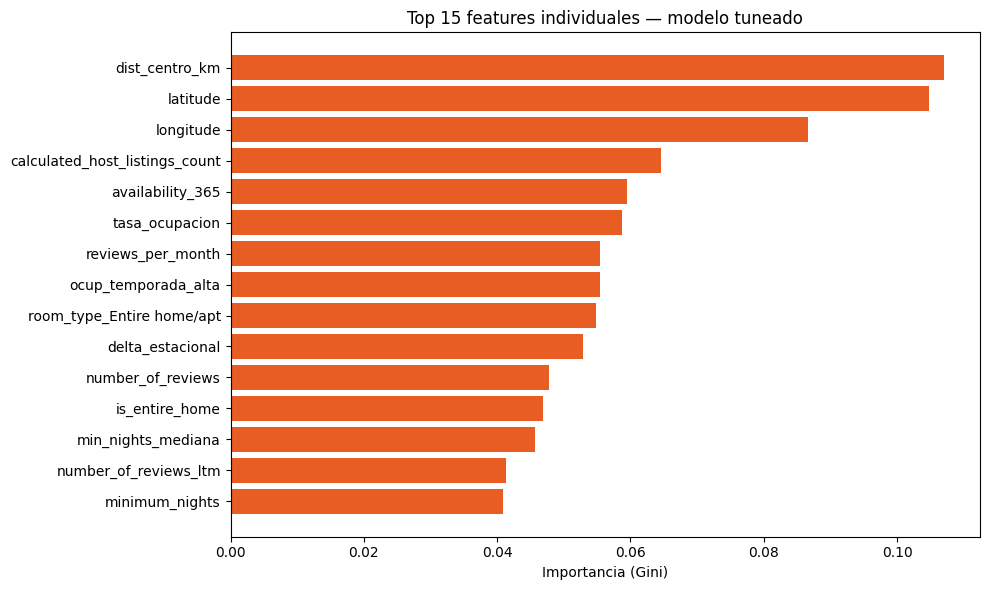

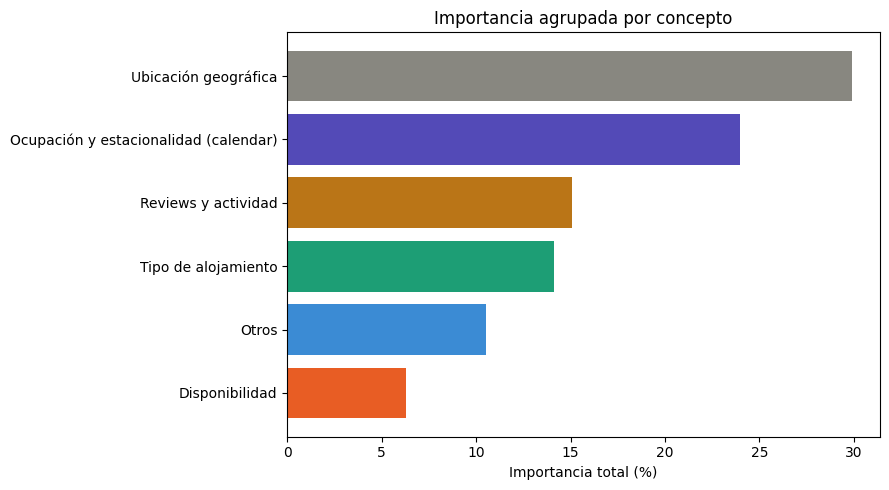


=== Importancia total por concepto ===
                                Grupo  Importancia (%)
                 Ubicación geográfica             29.9
Ocupación y estacionalidad (calendar)             24.0
                  Reviews y actividad             15.1
                  Tipo de alojamiento             14.1
                                Otros             10.5
                       Disponibilidad              6.3


In [57]:
# ── Nombres de todas las features tras el preprocesador ─────────────
numerical_feature_names   = columnas_numericas
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(columnas_categoricas)
all_feature_names = list(numerical_feature_names) + list(categorical_feature_names)

# Solo modelos basados en árboles tienen feature_importances_
importances = best_model.feature_importances_

all_importances = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top15 = all_importances.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1], color='#E85D24')
plt.title('Top 15 features individuales — modelo tuneado')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

# ── Importancia agrupada por concepto ────────────────────────────────
def grupo(f):
    if f in ['latitude', 'longitude', 'dist_centro_km']:
        return 'Ubicación geográfica'
    elif 'neighbourhood' in f:
        return 'Barrio (todas las dummies)'
    elif 'room_type' in f or f == 'is_entire_home':
        return 'Tipo de alojamiento'
    elif f in ['tasa_ocupacion','ocup_temporada_alta','ocup_temporada_baja',
               'delta_estacional','min_nights_mediana']:
        return 'Ocupación y estacionalidad (calendar)'
    elif 'review' in f or f == 'has_reviews':
        return 'Reviews y actividad'
    elif 'availability' in f or f == 'high_availability':
        return 'Disponibilidad'
    else:
        return 'Otros'

all_importances['Grupo'] = all_importances['Feature'].apply(grupo)
impacto_grupo = (all_importances
    .groupby('Grupo')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index())
impacto_grupo['Importancia (%)'] = (impacto_grupo['Importance'] * 100).round(1)

colors = ['#E85D24','#3B8BD4','#1D9E75','#BA7517','#534AB7','#888780','#D4A017']
plt.figure(figsize=(9, 5))
plt.barh(
    impacto_grupo['Grupo'][::-1],
    impacto_grupo['Importancia (%)'][::-1],
    color=colors[:len(impacto_grupo)]
)
plt.title('Importancia agrupada por concepto')
plt.xlabel('Importancia total (%)')
plt.tight_layout()
plt.show()

print('\n=== Importancia total por concepto ===')
print(impacto_grupo[['Grupo','Importancia (%)']].to_string(index=False))

### Interpretación de la importancia de las variables

El gráfico individual muestra que `latitude`, `longitude` y `dist_centro_km` tienen importancias individuales altas.

El gráfico agrupado, que suma las importancias de features relacionadas, muestra la realidad del mercado:

-   **Ubicación geográfica** (lat + lon + dist_centro_km): Este concepto es el más importante, capturando los gradientes de precio a nivel de calle. `dist_centro_km` sintetiza la señal radial en una sola variable. Es importante recordar que, aunque `neighbourhood` fue muy relevante en el análisis exploratorio, su contribución adicional al modelo final (más allá de `latitude`, `longitude` y `dist_centro_km`) se consideró mínima (0.1% de mejora en MAE), lo que llevó a su exclusión de las variables categóricas directas del modelo para simplificarlo y evitar redundancias. La importancia de la ubicación está fuertemente capturada por estas variables numéricas.
-   **Tipo de alojamiento** (room_type + is_entire_home): alquilar el apartamento completo impacta fuertemente en el precio.
-   **Ocupación y estacionalidad** (variables del calendar): confirma que la demanda real de un listing se refleja en su precio — los listings con alta tasa de ocupación cobran más.
-   **Reviews y disponibilidad**: capturan el perfil del anfitrión y la actividad del alojamiento.

### Justificación de `dist_centro_km` y `min_nights_mediana`

**1. `dist_centro_km` vs. `latitude` y `longitude`**

- **`latitude` y `longitude`**: Estas coordenadas permiten al modelo, especialmente a los modelos basados en árboles como Random Forest, identificar patrones espaciales y realizar divisiones en los datos basándose en ubicaciones específicas. Por ejemplo, el modelo puede aprender que las propiedades al norte de cierta latitud o al este de cierta longitud tienen un precio diferente.

- **`dist_centro_km`**: Esta variable complementa las coordenadas individuales al proporcionar una señal radial explícita desde un punto central conocido (Puerta del Sol). La distancia al centro es un factor de precio muy intuitivo en los mercados inmobiliarios, donde la centralidad a menudo se traduce directamente en mayor valor. Aunque `latitude` y `longitude` *podrían* capturar esta relación de forma implícita, `dist_centro_km` le da al modelo una medida continua y directa de "cuán céntrica" es una propiedad, facilitando la interpretación de esta relación. Los árboles de decisión pueden usar `dist_centro_km` para hacer splits más claros relacionados con la proximidad al centro, mejorando su capacidad predictiva en esta dimensión.


**2. `min_nights_mediana` vs. `minimum_nights`**

- **`minimum_nights`**: Esta variable, directamente del dataset de listings, representa la cantidad mínima de noches requeridas por el anfitrión en el momento de la extracción de los datos. Puede ser una política cambiante o específica para ciertas fechas.

- **`min_nights_mediana`**: Derivada del dataset de calendario, esta variable captura la *mediana* de las noches mínimas exigidas a lo largo de un año completo. A diferencia de `minimum_nights`, que es una instantánea, `min_nights_mediana` refleja una política más estable o la estrategia general del anfitrión. Por ejemplo:
    - Un anfitrión podría tener `minimum_nights = 1` en el listing, pero la `min_nights_mediana` podría ser `5` si durante la mayor parte del año solo acepta estancias de 5 o más noches.
    - Esto permite diferenciar alojamientos que consistentemente apuntan a estancias cortas de aquellos que buscan alquileres de mediano o largo plazo, los cuales a menudo tienen estructuras de precios diferentes (por ejemplo, precios por noche más bajos para estancias más largas).

Ambas variables, aunque relacionadas, ofrecen perspectivas distintas sobre la política de estadía mínima del anfitrión, y el modelo puede utilizarlas para capturar matices en las estrategias de precios.

### 3.2.6 Conclusiones

El modelo predice el precio por noche de alojamientos en Madrid con un **MAE de 43.69€** sobre el test set. Esto implica que el modelo se equivoca en promedio ~43.69€ por noche, sobre precios que típicamente oscilan entre 50€ y 200€.

**Hallazgos principales:**
- La **ubicación** es el factor dominante, explicando la mayor parte de la varianza de precios. Las variables `latitude`, `longitude` y `dist_centro_km` (distancia al centro) son cruciales para capturar el valor de la ubicación.
- El **tipo de alojamiento** (`room_type`, `is_entire_home`) es el segundo factor más relevante.
- Las **variables de ocupación del calendario** (`tasa_ocupacion`, `delta_estacional`, `min_nights_mediana`) agregaron información real de demanda y comportamiento del listing que las variables originales no contenían, mejorando el poder predictivo del modelo.
- El **feature engineering** agregó valor: `is_entire_home`, `dist_centro_km` y las variables derivadas del calendario resultaron ser features creados muy importantes según el modelo.
- La variable `neighbourhood` fue excluida del set de variables categóricas directas del modelo debido a su impacto mínimo (apenas 0.1% de mejora en el MAE) cuando se consideran `latitude`, `longitude` y `dist_centro_km`.
- El modelo **Random Forest** tuneado fue el que mejor desempeño obtuvo, superando a la Regresión Lineal, KNN y Gradient Boosting.

**Limitaciones:**
- El dataset de calendario cubre septiembre 2025 - septiembre 2026, mientras que el dataset de listings es de un período anterior. El join cubre aproximadamente el 60-70% de los listings; el 30-40% sin match fue imputado con la mediana.
- El dataset corresponde a un período específico; el modelo podría no generalizar bien a contextos con cambios estructurales en el mercado.
- No incluimos variables de texto (descripción, amenities) que podrían mejorar el poder predictivo.
- El dataset de Inside AirBnB puede tener sesgos de selección: solo incluye alojamientos activos en la plataforma.